# 🚀 Global Solution 2026 - SpaceGuardian AI
## Sistema Inteligente de Monitoramento e Predição de Falhas em Satélites LEO

## 1. Contextualização
A exploração espacial gera grandes volumes de telemetria. Este projeto utiliza IA, automação, banco de dados e análise de dados para prever falhas em satélites.

## 2. Objetivos
- Automatizar análise de telemetria
- Prever falhas
- Gerar alertas
- Armazenar histórico
- Produzir relatórios

## 3. Bibliotecas

In [15]:

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


## 4. Geração do Dataset Espacial

In [16]:

np.random.seed(42)

n=5000

df=pd.DataFrame({
'temperatura':np.random.randint(20,100,n),
'bateria':np.random.randint(5,100,n),
'sinal':np.random.randint(10,100,n),
'vibracao':np.random.randint(0,50,n),
'erros':np.random.randint(0,20,n),
'consumo_energia':np.random.randint(50,500,n)
})

def risco(row):
    if row['temperatura']>80 or row['bateria']<20:
        return 2
    elif row['sinal']<30 or row['erros']>10:
        return 1
    return 0

df['risco']=df.apply(risco,axis=1)

df.head()


,temperatura,bateria,sinal,vibracao,erros,consumo_energia,risco
0,71,22,13,44,14,160,1
1,34,73,89,17,18,401,1
2,91,58,89,28,9,467,2
3,80,34,94,34,11,61,1
4,40,49,35,37,5,70,0


## 5. Análise Exploratória

In [17]:

df.describe()


,temperatura,bateria,sinal,vibracao,erros,consumo_energia,risco
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,58.965600,52.325400,55.007600,24.371400,9.538200,274.811800,1.061800
std,22.858725,27.295079,26.104778,14.551901,5.768812,131.610611,0.787975
min,20.000000,5.000000,10.000000,0.000000,0.000000,50.000000,0.000000
25%,39.000000,29.000000,32.000000,12.000000,5.000000,158.000000,0.000000
50%,59.000000,53.000000,55.000000,24.000000,10.000000,279.000000,1.000000
75%,79.000000,76.000000,78.000000,37.000000,15.000000,391.000000,2.000000
max,99.000000,99.000000,99.000000,49.000000,19.000000,499.000000,2.000000


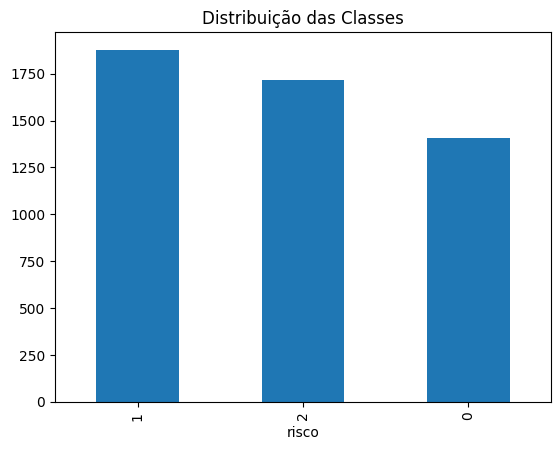

In [18]:

df['risco'].value_counts().plot(kind='bar')
plt.title('Distribuição das Classes')
plt.show()


## 6. Banco de Dados SQLite

In [19]:

conn = sqlite3.connect('spaceguardian.db')
df.to_sql('telemetria', conn, if_exists='replace', index=False)

pd.read_sql('SELECT * FROM telemetria LIMIT 5', conn)


,temperatura,bateria,sinal,vibracao,erros,consumo_energia,risco
0,71,22,13,44,14,160,1
1,34,73,89,17,18,401,1
2,91,58,89,28,9,467,2
3,80,34,94,34,11,61,1
4,40,49,35,37,5,70,0


## 7. Machine Learning

In [20]:

X=df.drop('risco',axis=1)
y=df['risco']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

modelo=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo.fit(X_train,y_train)

pred=modelo.predict(X_test)


## 8. Métricas

In [21]:

print('Acurácia:',accuracy_score(y_test,pred))
print(classification_report(y_test,pred))


Acurácia: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       274
           1       1.00      1.00      1.00       390
           2       1.00      1.00      1.00       336

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



## 9. Matriz de Confusão

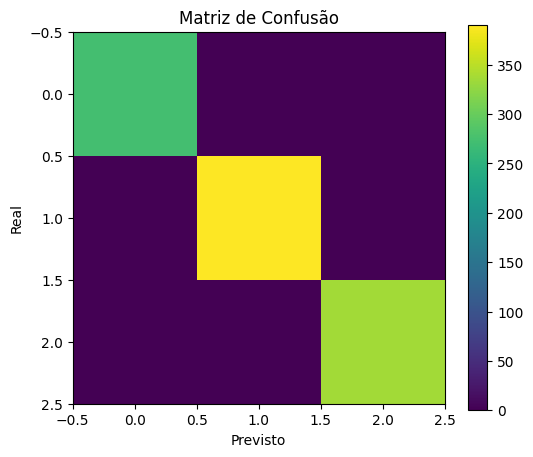

In [22]:

cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.colorbar()
plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()


## 10. Curva de Aprendizado

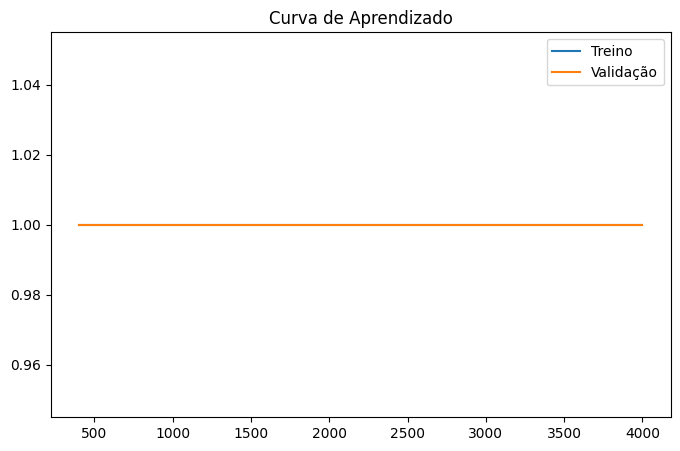

In [23]:

train_sizes, train_scores, test_scores = learning_curve(
    modelo,X,y,cv=5
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes,train_scores.mean(axis=1),label='Treino')
plt.plot(train_sizes,test_scores.mean(axis=1),label='Validação')
plt.title('Curva de Aprendizado')
plt.legend()
plt.show()


## 11. Simulação do Robô RPA

In [24]:

novo=pd.DataFrame({
'temperatura':[88],
'bateria':[12],
'sinal':[22],
'vibracao':[35],
'erros':[15],
'consumo_energia':[420]
})

resultado=modelo.predict(novo)[0]

if resultado==2:
    print('🚨 ALERTA CRÍTICO')
elif resultado==1:
    print('⚠️ ALERTA MODERADO')
else:
    print('✅ NORMAL')


🚨 ALERTA CRÍTICO


## 12. Simulação de API da NASA

In [25]:

# Exemplo para futura integração
# import requests
# resposta=requests.get('https://api.nasa.gov/...')
# dados=resposta.json()
print('Módulo preparado para integração com API NASA')


Módulo preparado para integração com API NASA


## 13. Dashboard Streamlit (Código Base)

In [26]:

streamlit_code = '''
import streamlit as st
import pandas as pd

st.title("SpaceGuardian AI")
st.dataframe(df.head())
'''
print(streamlit_code)



import streamlit as st
import pandas as pd

st.title("SpaceGuardian AI")
st.dataframe(df.head())



## 14. Resultados Esperados
Detecção antecipada de falhas, redução do tempo de análise e suporte às operações espaciais.

## 15. Conclusão
O projeto integra IA, RPA, Banco de Dados e Ciência de Dados em um cenário de exploração espacial, atendendo aos critérios da Global Solution 2026.

## 16. Feature Importance
Análise das variáveis mais relevantes para a previsão de falhas.

           feature  importance
0      temperatura    0.351304
4            erros    0.270081
1          bateria    0.229839
2            sinal    0.133387
5  consumo_energia    0.009007
3         vibracao    0.006382


<Axes: xlabel='feature'>

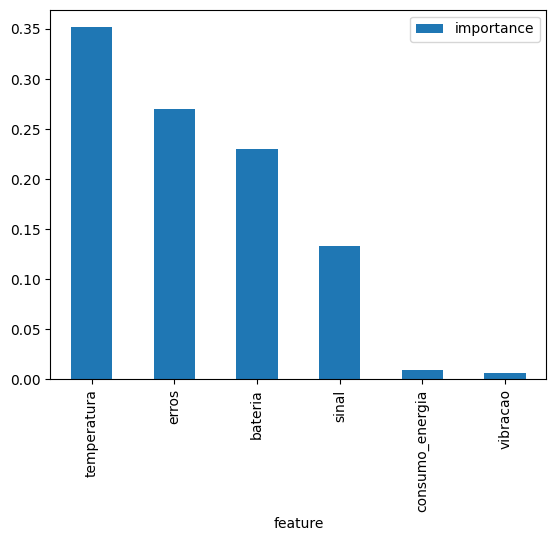

In [27]:
import pandas as pd
fi = pd.DataFrame({
    'feature': X.columns,
    'importance': modelo.feature_importances_
}).sort_values('importance', ascending=False)
print(fi)
fi.plot(x='feature', y='importance', kind='bar')

## 17. Exportação Automática de Relatórios
Geração de CSV para integração com fluxos RPA.

In [28]:
df.to_csv('telemetria_processada.csv', index=False)
print('Arquivo exportado com sucesso.')

Arquivo exportado com sucesso.
